In [1]:
import numpy as np
%matplotlib inline 
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize


/Users/suddin/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/gw/w6qdd1bn6zb2zrvd6dz7_9400000gp/T/matplotlib-zzcmrrf6 because there was an issue with the default path (/Users/suddin/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
dyld[81415]: symbol '_CGLSetCurrentContext' missing from root that overrides /System/Library/Frameworks/OpenGL.framework/Versions/A/Libraries/libGL.dylib. Use of that symbol in /System/Library/Frameworks/OpenGL.framework/Versions/A/OpenGL is being set to 0xBAD4007.
dyld[81415]: symbol '_CGLGetCurrentContext' missing from root that overrides /System/Library/Frameworks/OpenGL.framework/Versions/A/Libraries/libGL.dylib. Use of that symbol in /System/Library/Frameworks/OpenGL.framework/Versions/A/OpenGL is being set to 0xBAD4007.
dyld[81415]: symbol '_gll_noop' 

In [2]:
# -------------------------------------------------------------
# 1. Mock Supernova Dataset Generation (z, mu_obs, err)
# -------------------------------------------------------------
np.random.seed(42)
num_sne = 50
z_data = np.random.uniform(0.01, 1.0, num_sne)
z_data.sort()

# Fiducial cosmology for mocking data: H0=70, Om=0.3, OL=0.7
def dL_theory(z, Om, OL, H0=70.0):
    c = 299792.458 # km/s
    integrand = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + OL)
    integral, _ = quad(integrand, 0, z)
    return (c * (1 + z) / H0) * integral # Mpc

def mu_theory(z, Om, OL, H0=70.0):
    dL = dL_theory(z, Om, OL, H0)
    return 5.0 * np.log10(dL) + 25.0

# Generate synthetic measurements
mu_true = np.array([mu_theory(z, 0.3, 0.7) for z in z_data])
errors = np.random.normal(0.15, 0.03, num_sne)
mu_obs = mu_true + np.random.normal(0, errors)


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\O'
<>:17: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\O'
<>:17: SyntaxWarning: invalid escape sequence '\O'
/var/folders/gw/w6qdd1bn6zb2zrvd6dz7_9400000gp/T/ipykernel_81108/2214294537.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Distance Modulus ($\mu$)', fontsize=12)
/var/folders/gw/w6qdd1bn6zb2zrvd6dz7_9400000gp/T/ipykernel_81108/2214294537.py:16: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(z_grid, mu_flat_de, 'r-', linewidth=2, label='Flat Dark Energy ($\Omega_m=0.3, \Omega_\Lambda=0.7$)')
/var/folders/gw/w6qdd1bn6zb2zrvd6dz7_9400000gp/T/ipykernel_81108/2214294537.py:17: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(z_grid, mu_matter, 'b--', linewidth=2, label='Matter Only ($\Omega_m=1.0, \Omega_\Lambda=0.0$)')


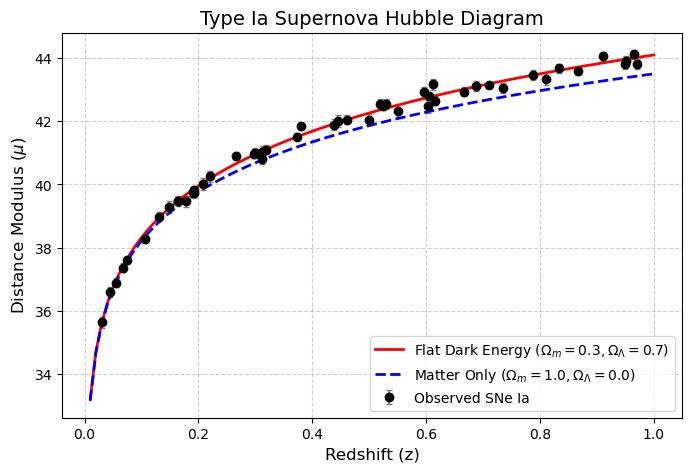

In [3]:
# -------------------------------------------------------------
# 2. Plotting the Hubble Diagram
# -------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.errorbar(z_data, mu_obs, yerr=errors, fmt='o', color='black', ecolor='gray', capsize=2, label='Observed SNe Ia')
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel('Distance Modulus ($\mu$)', fontsize=12)
plt.title('Type Ia Supernova Hubble Diagram', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Overlay theoretical curves
z_grid = np.linspace(0.01, 1.0, 100)
mu_flat_de = [mu_theory(z, 0.3, 0.7) for z in z_grid]
mu_matter  = [mu_theory(z, 1.0, 0.0) for z in z_grid]

plt.plot(z_grid, mu_flat_de, 'r-', linewidth=2, label='Flat Dark Energy ($\Omega_m=0.3, \Omega_\Lambda=0.7$)')
plt.plot(z_grid, mu_matter, 'b--', linewidth=2, label='Matter Only ($\Omega_m=1.0, \Omega_\Lambda=0.0$)')
plt.legend(fontsize=10)
plt.show()


In [4]:

# -------------------------------------------------------------
# 3. Parameter Fitting via Chi-Square Minimization
# -------------------------------------------------------------
def chi_square(params):
    Om = params[0]
    OL = 1.0 - Om # Assuming flat universe condition
    model = np.array([mu_theory(z, Om, OL) for z in z_data])
    return np.sum(((mu_obs - model) / errors)**2)

# Initial guess: Om = 0.5
res = minimize(chi_square, [0.5], bounds=[(0.0, 1.0)])

print(f"--- Best Fit Results ---")
print(f"Best-fit Omega_m : {res.x[0]:.3f}")
print(f"Best-fit Omega_L : {1.0 - res.x[0]:.3f}")

--- Best Fit Results ---
Best-fit Omega_m : 0.300
Best-fit Omega_L : 0.700
